# 06 — Backtest Report (Leakage-free)

This notebook backtests **out-of-sample (OOS)** model scores produced in `05_modeling.ipynb`.

**Input**
- `data/processed/oos_scores.parquet`

**Output**
- `results/backtest_summary.csv`
- `results/backtest_<model>.csv` (daily portfolio return + equity + turnover)
- Figures for the thesis (equity curves, rolling returns, turnover)

## Key choices (simple + defensible)
- Long/short, equal-weight
- Monthly rebalance (every 21 trading days)
- Daily P&L via realized `ret_1d`
- No transaction costs (turnover reported; costs can be discussed as limitation)


In [1]:
# --- project setup (so notebooks/ can import src/) ---
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from src.modeling.backtest import BacktestConfig, backtest_from_scores


In [2]:
# --- paths ---
OOS_PATH = PROJECT_ROOT / "data" / "processed" / "oos_scores.parquet"

OUT_SUMMARY = PROJECT_ROOT / "results" / "backtest_summary.csv"
OUT_DIR = PROJECT_ROOT / "results" / "backtest_artifacts"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OOS_PATH


PosixPath('/Users/igordragone/projects/hybrid-stock-prediction-thesis/data/processed/oos_scores.parquet')

In [3]:
# --- load OOS scores ---
oos = pd.read_parquet(OOS_PATH)
oos["date"] = pd.to_datetime(oos["date"])
oos = oos.sort_values(["date","ticker"]).reset_index(drop=True)

print("shape:", oos.shape)
print("date range:", oos["date"].min(), "→", oos["date"].max())
print("tickers:", oos["ticker"].nunique())
oos.head()


shape: (18590, 10)
date range: 2018-05-09 00:00:00 → 2025-09-30 00:00:00
tickers: 10


,date,ticker,ret_1d,ret_5d,ret_21d,fwd_ret_3_6m,target,baseline_score,ml_score,tree_score
0,2018-05-09,AAPL,0.004806,0.100236,0.094090,0.103016,0,0.766667,0.268357,-0.247694
1,2018-05-09,AMZN,-0.004843,0.006402,0.132503,0.097428,0,0.708333,0.107261,-0.543283
2,2018-05-09,GOOGL,-0.000821,0.017141,0.037742,0.070251,0,0.500000,0.159111,-0.107539
3,2018-05-09,JNJ,-0.007930,-0.026982,-0.053058,0.120263,0,0.125000,-0.746794,-0.156198
4,2018-05-09,KO,-0.007831,-0.018314,-0.046087,0.155216,1,0.200000,-0.944355,-0.106330


## 1) Configure backtest

In [4]:
# Models to backtest (name -> score column)
SCORES = {
    "baseline": "baseline_score",
    "logistic": "ml_score",
    "tree": "tree_score",
}

# Backtest config (monthly rebalance using ret_1d)
bt_cfg = BacktestConfig(
    date_col="date",
    ticker_col="ticker",
    ret_1d_col="ret_1d",
    rebalance_step=21,
    q=0.3,
    lag_weights_by_1d=True,
)

summary, artifacts = backtest_from_scores(oos, SCORES, bt_cfg)
summary


/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: _weights_for_date(x, score_col, cfg.q))
/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  port = d.groupby(cfg.date_col).apply(lambda x: (x["w_eff"] * x[cfg.ret_1d_col]).sum())
/Users/i

,model,mean_daily_return,vol_daily,sharpe_like,hit_ratio,max_drawdown,mean_turnover
0,tree,0.000484,0.016705,0.028997,0.513717,-0.409583,0.006599
1,baseline,0.000158,0.016932,0.009312,0.508338,-0.488485,0.006356
2,logistic,0.000025,0.018245,0.001344,0.499731,-0.752419,0.007387


## 2) Save artifacts

In [ ]:
# Save summary and per-model time series
summary.to_csv(OUT_SUMMARY, index=False)

for model_name, df_art in artifacts.items():
    out_path = OUT_DIR / f"backtest_{model_name}.csv"
    df_art.to_csv(out_path)
    print("saved:", out_path)

print("saved summary:", OUT_SUMMARY)


## 3) Equity curves (main figure)

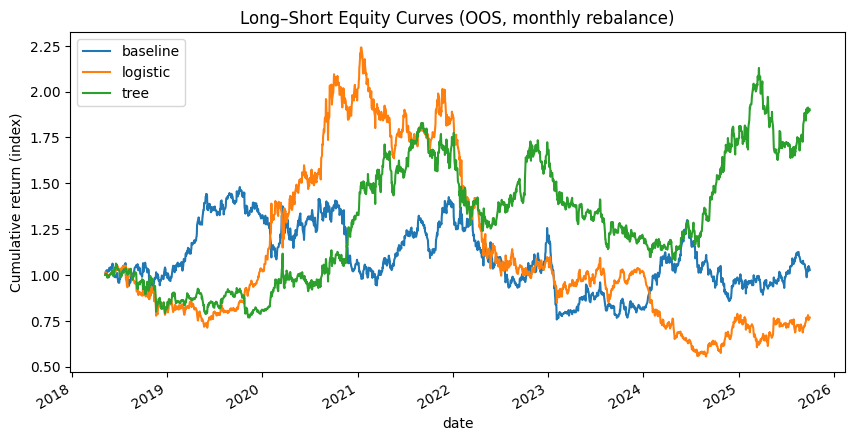

In [5]:
plt.figure(figsize=(10,5))
for model_name, df_art in artifacts.items():
    df_art["equity"].plot(label=model_name)
plt.title("Long–Short Equity Curves (OOS, monthly rebalance)")
plt.ylabel("Cumulative return (index)")
plt.legend()
plt.show()


## 4) Drawdowns (optional but good for thesis)

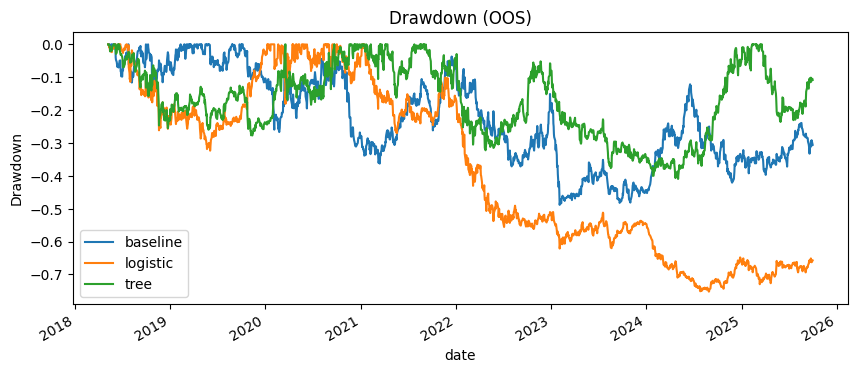

In [6]:
def drawdown(equity: pd.Series) -> pd.Series:
    return equity / equity.cummax() - 1.0

plt.figure(figsize=(10,4))
for model_name, df_art in artifacts.items():
    drawdown(df_art["equity"]).plot(label=model_name)
plt.title("Drawdown (OOS)")
plt.ylabel("Drawdown")
plt.legend()
plt.show()


## 5) Rolling mean returns (stability)

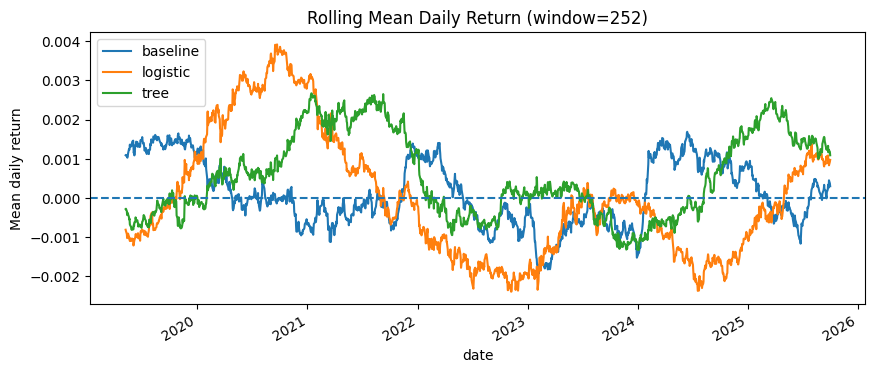

In [7]:
plt.figure(figsize=(10,4))
window = 252  # ~1 year
for model_name, df_art in artifacts.items():
    df_art["port_ret"].rolling(window).mean().plot(label=model_name)
plt.axhline(0, linestyle="--")
plt.title(f"Rolling Mean Daily Return (window={window})")
plt.ylabel("Mean daily return")
plt.legend()
plt.show()


## 6) Turnover (trading intensity proxy)

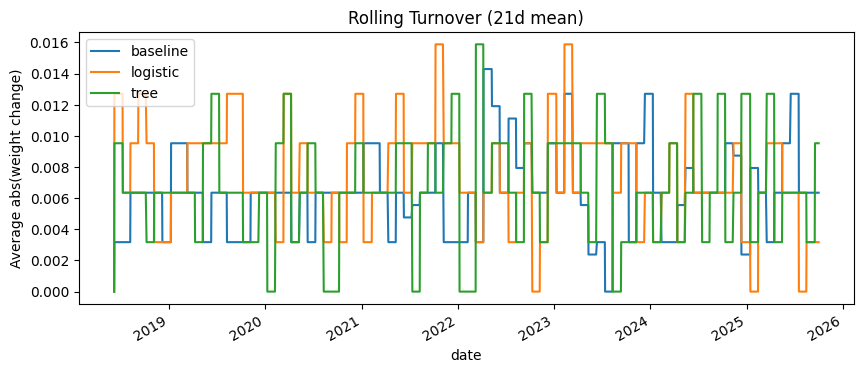

baseline mean turnover: 0.006356464048771741
logistic mean turnover: 0.007387484310561234
tree mean turnover: 0.0065985296754527524


In [8]:
plt.figure(figsize=(10,4))
for model_name, df_art in artifacts.items():
    df_art["turnover"].rolling(21).mean().plot(label=model_name)
plt.title("Rolling Turnover (21d mean)")
plt.ylabel("Average abs(weight change)")
plt.legend()
plt.show()

# Print average turnover
for model_name, df_art in artifacts.items():
    print(model_name, "mean turnover:", float(df_art["turnover"].mean()))


## 7) Final snapshot (easy to quote in thesis)

In [9]:
final_equity = {k: float(v["equity"].iloc[-1]) for k, v in artifacts.items()}
final_equity


{'baseline': 1.026834985108121,
 'logistic': 0.7676760586711975,
 'tree': 1.8981391205221985}

## Notes for the thesis

- The backtest is **OOS-only** because scores were generated fold-by-fold in `05_modeling.ipynb`.
- The portfolio is rebalanced monthly (every 21 trading days) to match the 3–6 month signal horizon.
- Transaction costs are not modeled; turnover is reported as a proxy and costs can be discussed as a limitation.


In [10]:
INITIAL_CAPITAL = 100.0  # euro (or dollars)

for model_name, df_art in artifacts.items():
    df_art["capital"] = INITIAL_CAPITAL * df_art["equity"]

# Show final capital
final_capital = {
    model_name: float(df_art["capital"].iloc[-1])
    for model_name, df_art in artifacts.items()
}
final_capital


{'baseline': 102.68349851081211,
 'logistic': 76.76760586711976,
 'tree': 189.81391205221985}

In [ ]:
def monthly_positions(df_scores, score_col, q=0.3):
    q_low = df_scores.groupby("date")[score_col].transform(lambda x: x.quantile(q))
    q_high = df_scores.groupby("date")[score_col].transform(lambda x: x.quantile(1-q))

    return np.where(
        df_scores[score_col] >= q_high, "BUY",
        np.where(df_scores[score_col] <= q_low, "SELL", "HOLD")
    )

example = oos.copy()
example["decision"] = monthly_positions(example, "tree_score", q=0.3)

example[["date","ticker","decision"]].head(20)
